# lgbm_3class_xfn5d_simple — Training & Hyperparameter Tuning

**Purpose**: Fully self-contained notebook that:
1. Loads the dataset, engineers the 5 new simple features, and defines all constants
2. Runs a walk-forward hyperparameter search over key LightGBM parameters
3. Selects the best configuration using the composite score (ASA + F1)
4. Trains the final production model on all available data
5. Saves a dated artifact

**Model**: `lgbm_3class_xfn5d_simple`  
**Features**: 15 (raw, explainable-only — no technical indicators, no macro/global risk)  
**Target**: `target_excess_xfn_5d` (5-day TD vs XFN excess return)  
**Threshold**: ±0.30%

See `feature_engineering.md` for full audit and rationale.


## 0. Setup

In [1]:
import sys, json, pickle, warnings
from pathlib import Path
from datetime import date
from itertools import product as iterproduct

import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path('').resolve()
ROOT         = NOTEBOOK_DIR.parents[1]          # project root
EXP_PARENT   = ROOT / 'step3_predictive_model/model_experiments_archive'
ARTIFACT_DIR = NOTEBOOK_DIR / 'artifacts'
ARTIFACT_DIR.mkdir(exist_ok=True)

for p in [str(ROOT), str(EXP_PARENT)]:
    if p not in sys.path:
        sys.path.insert(0, p)

print(f'ROOT         : {ROOT}')
print(f'Artifact dir : {ARTIFACT_DIR}')

ROOT         : /Users/yanyan/Desktop/Projects/AI_driven_company_and_stock_analysis
Artifact dir : /Users/yanyan/Desktop/Projects/AI_driven_company_and_stock_analysis/step3_predictive_model/simple_model/artifacts


## 1. Load Dataset & Engineer Simple Features

In [2]:
from redesign_single_stock.src.run_redesign_experiments import load_dataset, label_3class
from src.models.walk_forward_config import E10_FOLDS, STRIDE_EVAL

df = load_dataset()
print(f'Dataset loaded : {len(df)} rows  |  {df["date"].min().date()} → {df["date"].max().date()}')

# ── Engineer new simple features ───────────────────────────────────────────────
# call_decay is already computed inside load_dataset() but we re-derive it here
# for the new features, using the same half-life = 20 days
def call_decay_from_days(days: pd.Series, halflife: float = 20.0) -> pd.Series:
    return np.exp(-days.clip(lower=0).fillna(999.0) / halflife)

call_decay = call_decay_from_days(df['days_since_call'])

# evt_exec_tone: combined CEO + CFO prepared-remarks sentiment × call_decay
df['evt_exec_tone'] = (
    df[['transcript_ceo_prep_sentiment_mean_ffill',
        'transcript_cfo_prep_sentiment_mean_ffill']].mean(axis=1)
    * call_decay
)

# evt_guidance_topic / _sentiment: raw guidance topic share and sentiment × call_decay
df['evt_guidance_topic']     = df['topic_guidance_share_ffill']     * call_decay
df['evt_guidance_sentiment'] = df['topic_guidance_sentiment_ffill'] * call_decay

# evt_aml_topic / _sentiment: raw AML topic share and sentiment × call_decay
df['evt_aml_topic']     = df['topic_regulatory_AML_share_ffill']     * call_decay
df['evt_aml_sentiment'] = df['topic_regulatory_AML_sentiment_ffill'] * call_decay

print('New features engineered: evt_exec_tone, evt_guidance_topic, evt_guidance_sentiment, '
      'evt_aml_topic, evt_aml_sentiment')

Dataset loaded : 1285 rows  |  2021-02-25 → 2026-04-09
New features engineered: evt_exec_tone, evt_guidance_topic, evt_guidance_sentiment, evt_aml_topic, evt_aml_sentiment


## 2. Define Feature Constants

In [3]:
# ── 15-feature simple set ──────────────────────────────────────────────────────
# Group 1: Price & relative momentum (4)
PRICE_FEATURES = [
    'td_return_5d',
    'td_return_20d',
    'td_vs_xfn_5d',
    'td_dist_52w_high',
]

# Group 2: News (3)
NEWS_FEATURES = [
    'news_sent_mean_30d',
    'news_count_30d',
    'days_since_last_news',
]

# Group 3: Timing (2)
TIMING_FEATURES = [
    'days_since_call',
    'is_earnings_week',
]

# Group 4: NLP event signals (6) — 5 new + 1 carried from 35f
NLP_FEATURES = [
    'evt_exec_tone',           # new: mean(CEO, CFO) × call_decay
    'evt_framing_gap',         # from 35f: framing_gap_ffill × call_decay
    'evt_guidance_topic',      # new simplified: guidance_share × call_decay
    'evt_guidance_sentiment',  # new simplified: guidance_sentiment × call_decay
    'evt_aml_topic',           # new simplified: AML_share × call_decay
    'evt_aml_sentiment',       # new simplified: AML_sentiment × call_decay
]

FEATURES  = PRICE_FEATURES + NEWS_FEATURES + TIMING_FEATURES + NLP_FEATURES
TARGET    = 'target_excess_xfn_5d'
THRESHOLD = 0.003
label_map = {-1: 0, 0: 1, 1: 2}
inv_map   = {0: -1, 1: 0, 2: 1}

STRIDE  = STRIDE_EVAL
OFFSETS = list(range(STRIDE))

missing = [f for f in FEATURES if f not in df.columns]
assert not missing, f'Missing features: {missing}'

print(f'Features  : {len(FEATURES)}')
print(f'  Price   : {PRICE_FEATURES}')
print(f'  News    : {NEWS_FEATURES}')
print(f'  Timing  : {TIMING_FEATURES}')
print(f'  NLP     : {NLP_FEATURES}')
print(f'Target    : {TARGET}')
print(f'Threshold : ±{THRESHOLD*100:.2f}%')
print(f'Folds     : {len(E10_FOLDS)}')

Features  : 15
  Price   : ['td_return_5d', 'td_return_20d', 'td_vs_xfn_5d', 'td_dist_52w_high']
  News    : ['news_sent_mean_30d', 'news_count_30d', 'days_since_last_news']
  Timing  : ['days_since_call', 'is_earnings_week']
  NLP     : ['evt_exec_tone', 'evt_framing_gap', 'evt_guidance_topic', 'evt_guidance_sentiment', 'evt_aml_topic', 'evt_aml_sentiment']
Target    : target_excess_xfn_5d
Threshold : ±0.30%
Folds     : 7


## 3. Helper Functions

In [4]:
def offset_metrics(preds, y_true_cls, y_true_cont, dates):
    """Stride-5 offset-averaged metrics.
    active_asa uses the continuous excess return (signal-detector definition).
    """
    rows = []
    for off in OFFSETS:
        idx    = np.arange(off, len(dates), STRIDE)
        p      = preds[idx]
        y_cls  = y_true_cls[idx]
        y_cont = y_true_cont[idx]
        active = (p != 0)
        rows.append({
            'mean_acc':   (p == y_cls).mean(),
            'macro_f1':   f1_score(y_cls, p, average='macro', zero_division=0, labels=[-1, 0, 1]),
            'active_cov': active.mean(),
            'active_asa': float((np.sign(p[active]) == np.sign(y_cont[active])).mean())
                          if active.sum() > 0 else np.nan,
        })
    return pd.DataFrame(rows).mean()


def fit_with_params(train_df, test_df, params: dict):
    """Train LightGBM with given params and return predictions + labels."""
    x_tr  = train_df[FEATURES].fillna(train_df[FEATURES].median())
    y_tr  = label_3class(train_df[TARGET].values, threshold=THRESHOLD)
    y_enc = np.array([label_map[v] for v in y_tr], dtype=int)

    clf = lgb.LGBMClassifier(
        objective='multiclass', num_class=3,
        random_state=42, verbose=-1, n_jobs=1, **params
    )
    clf.fit(x_tr, y_enc)

    x_te      = test_df[FEATURES].fillna(train_df[FEATURES].median())
    y_te_cls  = label_3class(test_df[TARGET].values, threshold=THRESHOLD)
    y_te_cont = test_df[TARGET].values
    preds_enc = clf.predict(x_te)
    preds     = np.array([inv_map[p] for p in preds_enc])
    return clf, preds, y_te_cls, y_te_cont


print('Helper functions defined.')

Helper functions defined.


## 4. Hyperparameter Search

Same grid as the 35f model — allows apples-to-apples comparison of best configs.

| Param | Values | Default |
|---|---|---|
| `num_leaves` | 4, 8, 16, 31 | 8 |
| `min_child_samples` | 20, 40, 60 | 40 |
| `n_estimators` | 80, 120, 200 | 120 |

**Selection criterion**: composite = `0.6 × active_asa + 0.4 × macro_f1`

In [5]:
BASE_PARAMS = dict(
    learning_rate=0.05, feature_fraction=0.8,
    reg_alpha=0.2, reg_lambda=1.0,
)

GRID = {
    'num_leaves':        [4, 8, 16, 31],
    'min_child_samples': [20, 40, 60],
    'n_estimators':      [80, 120, 200],
}

combos = list(iterproduct(
    GRID['num_leaves'], GRID['min_child_samples'], GRID['n_estimators']
))
print(f'Running {len(combos)} configs × {len(E10_FOLDS)} folds …\n')

search_rows = []
for i, (nl, mcs, ne) in enumerate(combos, 1):
    params = {**BASE_PARAMS, 'num_leaves': nl, 'min_child_samples': mcs, 'n_estimators': ne}
    fold_ms = []
    for fold_id, train_end, test_start, test_end in E10_FOLDS:
        tr_mask = (df['date'] <= pd.Timestamp(train_end)) & df[TARGET].notna()
        te_mask = ((df['date'] >= pd.Timestamp(test_start)) &
                   (df['date'] <= pd.Timestamp(test_end)) & df[TARGET].notna())
        _, preds, y_cls, y_cont = fit_with_params(df[tr_mask], df[te_mask], params)
        fold_ms.append(offset_metrics(preds, y_cls, y_cont, df[te_mask]['date'].values))

    agg  = pd.DataFrame(fold_ms).mean()
    comp = 0.6 * float(agg.active_asa) + 0.4 * float(agg.macro_f1)
    search_rows.append({
        'num_leaves': nl, 'min_child_samples': mcs, 'n_estimators': ne,
        'mean_acc':   round(float(agg.mean_acc),   3),
        'macro_f1':   round(float(agg.macro_f1),   3),
        'active_asa': round(float(agg.active_asa),  3),
        'active_cov': round(float(agg.active_cov),  3),
        'composite':  round(comp, 4),
    })
    print(f'[{i:2d}/{len(combos)}]  leaves={nl:2d}  mcs={mcs:2d}  ne={ne:3d}  '
          f'asa={agg.active_asa:.3f}  f1={agg.macro_f1:.3f}  composite={comp:.4f}')

print('\nSearch complete.')

Running 36 configs × 7 folds …



[ 1/36]  leaves= 4  mcs=20  ne= 80  asa=0.521  f1=0.314  composite=0.4383


[ 2/36]  leaves= 4  mcs=20  ne=120  asa=0.521  f1=0.315  composite=0.4384


[ 3/36]  leaves= 4  mcs=20  ne=200  asa=0.511  f1=0.310  composite=0.4306


[ 4/36]  leaves= 4  mcs=40  ne= 80  asa=0.526  f1=0.312  composite=0.4401


...

[32/36]  leaves=31  mcs=40  ne=120  asa=0.518  f1=0.310  composite=0.4350


[33/36]  leaves=31  mcs=40  ne=200  asa=0.526  f1=0.321  composite=0.4439


[34/36]  leaves=31  mcs=60  ne= 80  asa=0.515  f1=0.306  composite=0.4318


[35/36]  leaves=31  mcs=60  ne=120  asa=0.517  f1=0.299  composite=0.4299


[36/36]  leaves=31  mcs=60  ne=200  asa=0.503  f1=0.295  composite=0.4198

Search complete.


## 5. Results & Best Configuration

In [6]:
search_df = (
    pd.DataFrame(search_rows)
    .sort_values('composite', ascending=False)
    .reset_index(drop=True)
)
search_df.index += 1

print('=== Search results (sorted by composite score = 0.6×ASA + 0.4×F1) ===\n')
display(search_df[['num_leaves','min_child_samples','n_estimators',
                    'active_asa','macro_f1','mean_acc','active_cov','composite']])

best_row  = search_df.iloc[0]
BEST_PARAMS = {
    **BASE_PARAMS,
    'num_leaves':        int(best_row.num_leaves),
    'min_child_samples': int(best_row.min_child_samples),
    'n_estimators':      int(best_row.n_estimators),
}

print(f'\n── Best configuration (rank 1 by composite) ──')
for k, v in BEST_PARAMS.items():
    print(f'  {k}: {v}')
print(f'\n  ASA       : {best_row.active_asa:.3f}')
print(f'  Macro F1  : {best_row.macro_f1:.3f}')
print(f'  Mean acc  : {best_row.mean_acc:.3f}')
print(f'  Composite : {best_row.composite:.4f}')

=== Search results (sorted by composite score = 0.6×ASA + 0.4×F1) ===



,num_leaves,min_child_samples,n_estimators,active_asa,macro_f1,mean_acc,active_cov,composite
1,4,40,200,0.542,0.325,0.414,0.931,0.4550
2,8,60,120,0.532,0.328,0.406,0.923,0.4507
3,31,40,80,0.529,0.328,0.402,0.940,0.4483
4,4,40,120,0.530,0.321,0.410,0.948,0.4464
5,31,40,200,0.526,0.321,0.392,0.923,0.4439
6,4,40,80,0.526,0.312,0.406,0.969,0.4401
7,8,60,80,0.520,0.319,0.411,0.952,0.4397
8,4,20,120,0.521,0.315,0.409,0.962,0.4384
9,4,20,80,0.521,0.314,0.408,0.970,0.4383
10,16,60,80,0.524,0.310,0.405,0.955,0.4383



── Best configuration (rank 1 by composite) ──
  learning_rate: 0.05
  feature_fraction: 0.8
  reg_alpha: 0.2
  reg_lambda: 1.0
  num_leaves: 4
  min_child_samples: 40
  n_estimators: 200

  ASA       : 0.542
  Macro F1  : 0.325
  Mean acc  : 0.414
  Composite : 0.4550


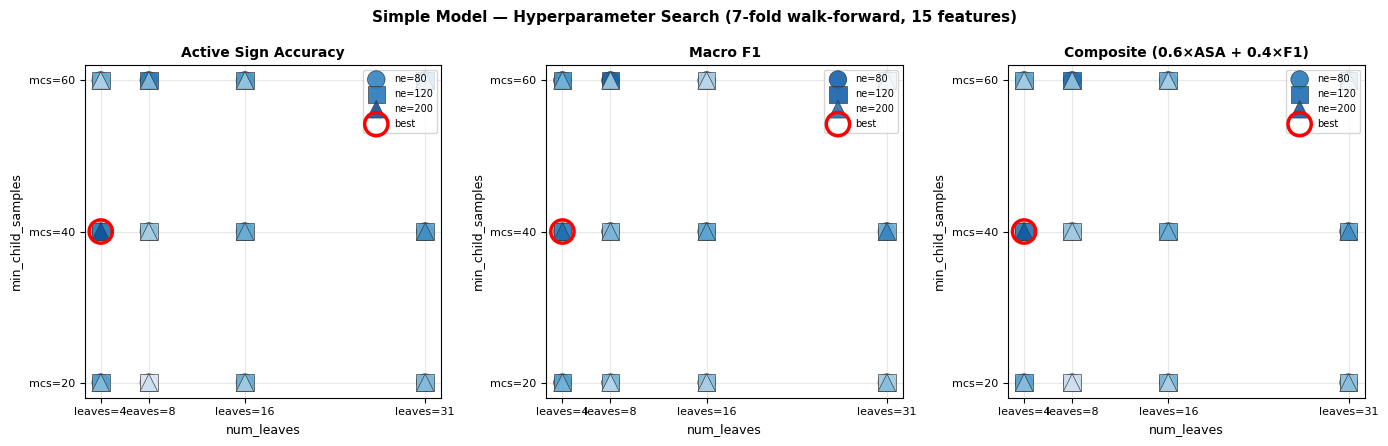

In [7]:
# ── Bubble chart: composite score across the grid ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
ne_vals  = GRID['n_estimators']
colors   = ['#4a7cf6', '#f0a500', '#e55a5a']
markers  = ['o', 's', '^']

for ax, (metric, label) in zip(axes, [
    ('active_asa', 'Active Sign Accuracy'),
    ('macro_f1',   'Macro F1'),
    ('composite',  'Composite (0.6×ASA + 0.4×F1)'),
]):
    for ne, color, marker in zip(ne_vals, colors, markers):
        sub = search_df[search_df.n_estimators == ne]
        ax.scatter(sub.num_leaves, sub.min_child_samples,
                   s=160, c=sub[metric], cmap='Blues',
                   vmin=search_df[metric].min()-0.01,
                   vmax=search_df[metric].max()+0.01,
                   marker=marker, edgecolors='#333', linewidths=0.5,
                   label=f'ne={ne}', alpha=0.9, zorder=3)

    ax.scatter(int(best_row.num_leaves), int(best_row.min_child_samples),
               s=280, c='none', edgecolors='red', linewidths=2.5,
               zorder=4, label='best')

    ax.set_xticks(GRID['num_leaves'])
    ax.set_xticklabels([f'leaves={v}' for v in GRID['num_leaves']], fontsize=8)
    ax.set_yticks(GRID['min_child_samples'])
    ax.set_yticklabels([f'mcs={v}' for v in GRID['min_child_samples']], fontsize=8)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('num_leaves', fontsize=9)
    ax.set_ylabel('min_child_samples', fontsize=9)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle('Simple Model — Hyperparameter Search (7-fold walk-forward, 15 features)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Train Final Model

In [8]:
full_df    = df[df[TARGET].notna()].copy()
train_end  = full_df['date'].max()

x_full = full_df[FEATURES].fillna(full_df[FEATURES].median())
y_full = label_3class(full_df[TARGET].values, threshold=THRESHOLD)
y_enc  = np.array([label_map[v] for v in y_full], dtype=int)

final_clf = lgb.LGBMClassifier(
    objective='multiclass', num_class=3,
    random_state=42, verbose=-1, n_jobs=1,
    **BEST_PARAMS,
)
final_clf.fit(x_full, y_enc)

print(f'Trained on : {len(full_df)} rows')
print(f'Date range : {full_df["date"].min().date()} → {train_end.date()}')
print(f'Params     : {BEST_PARAMS}')
print('Training complete ✓')

Trained on : 1285 rows
Date range : 2021-02-25 → 2026-04-09
Params     : {'learning_rate': 0.05, 'feature_fraction': 0.8, 'reg_alpha': 0.2, 'reg_lambda': 1.0, 'num_leaves': 4, 'min_child_samples': 40, 'n_estimators': 200}
Training complete ✓


## 7. Save Artifact

In [9]:
TODAY       = date.today().isoformat()
ARTIFACT_ID = f'lgbm_3class_xfn5d_simple_tuned-{TODAY}'
PKL_PATH    = ARTIFACT_DIR / f'{ARTIFACT_ID}.pkl'
JSON_PATH   = ARTIFACT_DIR / f'{ARTIFACT_ID}.json'

artifact = {
    'model':              final_clf,
    'features':           FEATURES,
    'target':             TARGET,
    'threshold':          THRESHOLD,
    'label_map':          label_map,
    'inverse_label_map':  inv_map,
    'best_params':        BEST_PARAMS,
    'train_rows':         len(full_df),
    'train_end':          str(train_end.date()),
    'artifact_id':        ARTIFACT_ID,
}
with open(PKL_PATH, 'wb') as f:
    pickle.dump(artifact, f)

meta = {
    'artifact_id':     ARTIFACT_ID,
    'model_name':      'lgbm_3class_xfn5d_simple',
    'artifact_type':   'tuned',
    'created':         TODAY,
    'source':          'lgbm_3class_xfn5d_simple_training.ipynb',
    'description':     (
        'LightGBM 3-class signal model (outperform / neutral / underperform vs XFN). '
        '15-feature explainable-only set (no technical indicators, no macro/global risk). '
        'Hyperparameters selected via 36-config × 7-fold walk-forward search, '
        'composite score = 0.6×ASA + 0.4×F1. '
        'Production model trained on all available data.'
    ),
    'best_params':     BEST_PARAMS,
    'search_winner':   {
        'active_asa':  float(best_row.active_asa),
        'macro_f1':    float(best_row.macro_f1),
        'composite':   float(best_row.composite),
        'rank':        1,
    },
    'features':        FEATURES,
    'n_features':      len(FEATURES),
    'target':          TARGET,
    'threshold':       THRESHOLD,
    'train_rows':      int(len(full_df)),
    'train_end':       str(train_end.date()),
    'artifact_path':   str(PKL_PATH),
}
with open(JSON_PATH, 'w') as f:
    json.dump(meta, f, indent=2)

print(f'Saved PKL  : {PKL_PATH.name}')
print(f'Saved JSON : {JSON_PATH.name}')
print()
print('Existing artifacts in folder:')
for p in sorted(ARTIFACT_DIR.glob('*.pkl')):
    print(f'  {p.name}')

Saved PKL  : lgbm_3class_xfn5d_simple_tuned-2026-04-23.pkl
Saved JSON : lgbm_3class_xfn5d_simple_tuned-2026-04-23.json

Existing artifacts in folder:
  lgbm_3class_xfn5d_simple_tuned-2026-04-23.pkl
